# COMSOL transmon capacitance and field

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"          # or: pip install "qpdk[comsol]"
uv sync --extra comsol         # from a checkout of this repository
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** Running
the model build and the electrostatic solve needs a local COMSOL installation
and a license. Google Colab has neither, so the build cells cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

This notebook extracts the two capacitor pads of a QPDK double-pad transmon,
builds a COMSOL sheet model around them, solves the electrostatic problem, and
reads back the pad capacitance and stored energy. The committed results and the
field map at the end come from an actual COMSOL 6.3 solve. The build and solve
cells are gated behind `RUN_COMSOL` because they need a license; set it to
`True` on a licensed machine to reproduce them, and the notebook still runs and
still plots the committed data with `RUN_COMSOL = False`.
If running a downloaded copy outside a repository checkout, place the
[metrics JSON](data/comsol_qubit_metrics.json)
and [field TXT](data/comsol_qubit_field.txt)
in a `data/` directory next to the notebook.

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`: two rectangular
capacitor pads separated by a small gap, with a SQUID loop at the centre. The
pads dominate the total capacitance $C$, and the SQUID supplies the Josephson
energy $E_J$, so the qubit transition frequency is set by $E_J$ and the
charging energy $E_C = e^2 / 2C$ {cite:p}`kochChargeinsensitiveQubitDesign2007a`.

In the real device the pads are joined **only** through the Josephson
junction. The QPDK cell draws the SQUID's leads and contact patches on
`JJ_AREA` and `JJ_PATCH`, and those oxide barriers are not metal shorts. The
extraction here works on an **EM-only copy** with those two layers removed, so
the SQUID loop and its leads are not part of the solved geometry and their
parasitic inductance and capacitance are omitted. What remains is the two pads
and the surrounding ground plane, which is exactly what the pad capacitance
needs.

## What the solve is, and what it is not

The physics added is **Electrostatics**, not electromagnetic waves:

- The left pad is driven by a voltage terminal, and the right pad and the
  ground plane are held at ground.
- The solve returns `es.C11`, the capacitance of the driven pad to the grounded
  rest of the chip, and `es.intWe`, the stored electric energy. The two agree,
  since $2 W_e / V^2 = C_{11}$.

This is a **quasi-static capacitance extraction**. It says nothing about a
resonance, because there is no resonant element in the model: no Josephson
inductance is present, and the metal is a perfect conductor.

### The LC frequency is an estimate, not an eigenmode

Given $C_{11}$ one can pick a Josephson inductance $L_J$ and form
$f_{LC} = 1 / (2 \pi \sqrt{L_J C_{11}})$. That number is an **estimate**: it uses
an inductance that is not in the COMSOL model, and it is neither a COMSOL
eigenfrequency nor the transmon $f_{01}$. The true $f_{01}$ also carries the
$E_C$ anharmonic correction and the qubit spectrum is found from a Hamiltonian
treatment, which QPDK's scQubits notebook and {cite:p}`groszkowskiScqubitsPythonPackage2021`
provide. The value below is labelled an estimate wherever it appears.

**References:**
- QPDK transmon physics and the double-pad cell: {py:func}`~qpdk.cells.transmon.double_pad_transmon_with_bbox`
- [COMSOL Electrostatics interface](https://doc.comsol.com/6.3/doc/com.comsol.help.acdc/acdc_ug_electric_fields.07.002.html)
- [COMSOL capacitance example](https://doc.comsol.com/6.3/doc/com.comsol.help.models.acdc.capacitor_dc/capacitor_dc.html)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cells below "
        "cannot run in Colab."
    )

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.transmon import double_pad_transmon_with_bbox
from qpdk.config import PATH
from qpdk.simulation import (
    add_qubit_capacitance_study,
    build_comsol_sheet_model,
    prepare_comsol_layout,
)
from qpdk.tech import LAYER

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None

#: Committed COMSOL results, either relative to the repository root or to a
#: working directory of `notebooks/`.
_DATA_DIR_CANDIDATES = (
    PATH.repo / "notebooks" / "data",
    Path("notebooks/data"),
    Path("data"),
)


def data_path(name: str) -> Path:
    """Return the path of a committed data file in ``notebooks/data``.

    Returns:
        The first existing candidate path.

    Raises:
        FileNotFoundError: If no candidate holds the file.
    """
    for directory in _DATA_DIR_CANDIDATES:
        candidate = directory / name
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"{name!r} not found in {[str(directory) for directory in _DATA_DIR_CANDIDATES]}"
    )

## Build the transmon cell and an EM-only copy

`prepare_comsol_layout` rejects components carrying geometry on layers it does
not model, and the junction layers are among those. The simplification is made
explicit here: the cell is copied and `JJ_AREA` and `JJ_PATCH` are removed, so
only `M1_DRAW` and the `M1_ETCH` mask it is inverted from remain.

In [3]:
component = double_pad_transmon_with_bbox(bbox_extension=200.0)

junction_port = component.ports["junction"]
JUNCTION_CENTER_UM = tuple(junction_port.center)

em_component = component.copy()
em_component.remove_layers(layers=[LAYER.JJ_AREA, LAYER.JJ_PATCH])

print(f"Component: {component.name}")
print(f"Bounding box (µm): {component.bbox()}")
print(f"Junction site: center={JUNCTION_CENTER_UM} µm")
print(f"Layers kept:   {sorted(em_component.layers)}")
print("JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.")

Component: double_pad_transmon_with_bbox_BE200_PS250_400_PG15_JSsq_c3fdad3b
Bounding box (µm): (-457.5,-400;457.5,400)
Junction site: center=(0.0, 0.0) µm
Layers kept:   [(1, 0), (1, 1)]
JJ_AREA/JJ_PATCH removed; M1_DRAW and M1_ETCH remain.


## Extract the COMSOL layout

The qubit pads are not transmission-line ports, so the extraction is asked for
no feed ports. The etched moat is a *hole* in the ground-plane polygon; the two
pads sit inside it as separate metal polygons.

In [4]:
layout = prepare_comsol_layout(em_component, feed_ports=None, ground_margin=100.0)

print(f"Metal polygons: {len(layout.polygons)}")
print(f"Feed ports:     {layout.feed_ports}")
print(f"Prepared bbox (µm): {layout.bbox}")

# Three conductor faces: the two pads and the ground plane. Each point below
# sits well inside its metal region so the face selection resolves to exactly
# one face, which the study builder checks before adding the terminals.
LEFT_PAD_POINT = (-132.5, 0.0)
RIGHT_PAD_POINT = (132.5, 0.0)
GROUND_POINT = (-500.0, 0.0)

Metal polygons: 3
Feed ports:     ()
Prepared bbox (µm): ComsolBoundingBox(xmin=-557.5, ymin=-500.0, xmax=557.5, ymax=500.0)


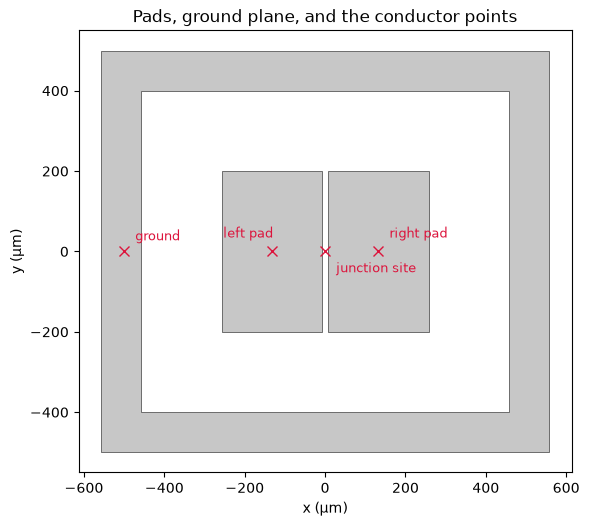

In [5]:
fig, ax = plt.subplots(figsize=(6, 6))
for polygon in sorted(
    layout.polygons,
    key=lambda item: (
        -(
            (max(x for x, _ in item.outline) - min(x for x, _ in item.outline))
            * (max(y for _, y in item.outline) - min(y for _, y in item.outline))
        )
    ),
):
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=1,
            )
        )
for point, label, offset in (
    (LEFT_PAD_POINT, "left pad", (-35, 10)),
    (RIGHT_PAD_POINT, "right pad", (8, 10)),
    (GROUND_POINT, "ground", (8, 8)),
    (JUNCTION_CENTER_UM, "junction site", (8, -15)),
):
    ax.plot(*point, marker="x", color="crimson", markersize=7, zorder=4)
    ax.annotate(
        label,
        point,
        textcoords="offset points",
        xytext=offset,
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Pads, ground plane, and the conductor points")
plt.tight_layout()
plt.show()

## Build the COMSOL model and capacitance study

Two calls configure the model:

- {py:func}`~qpdk.simulation.comsol_sheet.build_comsol_sheet_model` creates the
  air and silicon blocks meeting at $z = 0$, imprints the layout metal on that
  interface as faces, and assigns materials ($\epsilon_r = 1$ air,
  $\epsilon_r = 11.7$ silicon).
- {py:func}`~qpdk.simulation.comsol_capacitance.add_qubit_capacitance_study`
  picks the two pad faces and the ground face with the points above, drives the
  left pad with a voltage terminal, grounds the right pad and the ground plane,
  and adds the mesh and a stationary study. The selection builder refuses a
  point that does not land on exactly one face, so a wrong point fails loudly
  instead of grounding the wrong area.

`mph.start(cores=...)` launches a COMSOL server process and attaches to it.
Only one MPh client can exist per Python process, and the call needs a COMSOL
installation and a license. The block is off by default so the notebook runs
without one; set `RUN_COMSOL = True` on a licensed machine to build, solve, and
save the model.

In [6]:
RUN_COMSOL = False
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_qubit_capacitance.mph"
CORES = 4
VOLTAGE_V = 1.0

model = None
if RUN_COMSOL and not MPH_AVAILABLE:
    raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")

if RUN_COMSOL and MPH_AVAILABLE:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)
    model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Double-Pad Transmon",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    add_qubit_capacitance_study(
        model,
        layout,
        left_pad_point=LEFT_PAD_POINT,
        right_pad_point=RIGHT_PAD_POINT,
        ground_point=GROUND_POINT,
        voltage_v=VOLTAGE_V,
        mesh_size=7,
    )
    model.java.component("comp1").mesh("mesh1").run()
    model.java.study("std1").run()
    model.save(MODEL_PATH)

    capacitance_f = float(model.evaluate("es.C11"))
    stored_energy_j = float(model.evaluate("es.intWe"))
    print(f"es.C11 = {capacitance_f:.6e} F")
    print(f"es.intWe = {stored_energy_j:.6e} J")
    print(f"2*intWe/V^2 = {2.0 * stored_energy_j / VOLTAGE_V**2:.6e} F")
    print(f"Saved model to {MODEL_PATH}")

    metrics_path = MODEL_DIR / "comsol_qubit_metrics.json"
    metrics_path.write_text(
        json.dumps(
            {
                "capacitance_f": capacitance_f,
                "stored_energy_j": stored_energy_j,
                "voltage_v": VOLTAGE_V,
                "solver": "COMSOL Multiphysics",
                "study": "Electrostatics stationary",
                "mesh_size": 7,
                "substrate_thickness_um": 200.0,
                "air_height_um": 200.0,
                "silicon_relative_permittivity": 11.7,
            },
            indent=2,
        )
        + "\n"
    )

### Exporting the potential and field map

The committed field data in `notebooks/data/comsol_qubit_field.txt` was written
from the solved model with COMSOL's Data export on a cut plane at $z = 1$ µm,
carrying the potential $V$ and the field norm `es.normE`. The same export is
scripted below: a `CutPlane` dataset over the $xy$ plane, then a `Data` result
export listing both expressions. It runs inside the licensed branch and writes
a file of the same shape as the committed one.

In [7]:
if RUN_COMSOL and MPH_AVAILABLE and model is not None:
    plane = model.java.result().dataset().create("cutplane", "CutPlane")
    plane.set("planetype", "quick")
    plane.set("quickplane", "xy")
    plane.set("quickz", "1[um]")
    plane.set("data", "dset1")

    field_export = model.java.result().export().create("field", "Data")
    field_export.set("data", "cutplane")
    field_export.set("expr", ["V", "es.normE"])
    field_export.set("filename", str(MODEL_DIR / "comsol_qubit_field.txt"))
    field_export.run()
    print(f"Exported V and es.normE to {MODEL_DIR / 'comsol_qubit_field.txt'}")

## Saved capacitance result

The committed metrics come from the electrostatic solve above. `C11` is the
capacitance of the driven pad to the grounded rest of the chip, and the stored
energy is checked against it through $2 W_e / V^2$. This one-terminal
$C_{11}$ does not by itself give the differential-mode capacitance of the
two floating pads, so it is not yet the transmon charging capacitance.

In [8]:
results_dir = MODEL_DIR if RUN_COMSOL else None
metrics_file = (
    results_dir / "comsol_qubit_metrics.json"
    if results_dir is not None
    else data_path("comsol_qubit_metrics.json")
)
metrics = json.loads(metrics_file.read_text())
capacitance_f = float(metrics["capacitance_f"])
stored_energy_j = float(metrics["stored_energy_j"])
voltage_v = float(metrics["voltage_v"])

capacitance_from_energy_f = 2.0 * stored_energy_j / voltage_v**2

print(f"es.C11                       = {capacitance_f:.6e} F")
print(f"2 * es.intWe / V^2           = {capacitance_from_energy_f:.6e} F")
print(
    "relative difference          = "
    f"{abs(capacitance_from_energy_f - capacitance_f) / capacitance_f:.2e}"
)
for key in ("version", "mesh"):
    if key in metrics:
        print(f"{key:<28} = {metrics[key]}")

es.C11                       = 1.751443e-13 F
2 * es.intWe / V^2           = 1.751443e-13 F
relative difference          = 1.44e-16


### An LC frequency estimate

With $C_{11}$ in hand, a Josephson inductance $L_J$ gives a rough scale for the
circuit frequency. **$L_J$ is not part of the COMSOL solve**, and $C_{11}$ is
not the two-pad differential capacitance. The resulting number only shows the
scale one would get from these illustrative circuit values; it is not an
eigenfrequency or the transmon $f_{01}$.

In [9]:
LJ_H = 10e-9  # chosen, not solved for
f_lc_ghz = 1.0 / (2.0 * np.pi * np.sqrt(LJ_H * capacitance_f)) / 1e9
print(f"Chosen L_J                    = {LJ_H * 1e9:.1f} nH")
print(f"illustrative f_LC using C11     = {f_lc_ghz:.3f} GHz")
print("L_J is not in the model; C11 is not the differential pad capacitance.")

Chosen L_J                    = 10.0 nH
illustrative f_LC using C11     = 3.803 GHz
L_J is not in the model; C11 is not the differential pad capacitance.


## Saved potential and field map

The exported field is the potential $V$ and the electric-field norm on the
$z = 1$ µm plane. The metal sheet lies at $z = 0$ and the plane sits just above
it, so the map shows the potential holding across the driven pad and the field
concentrating in the pad gap and along the pad edges.

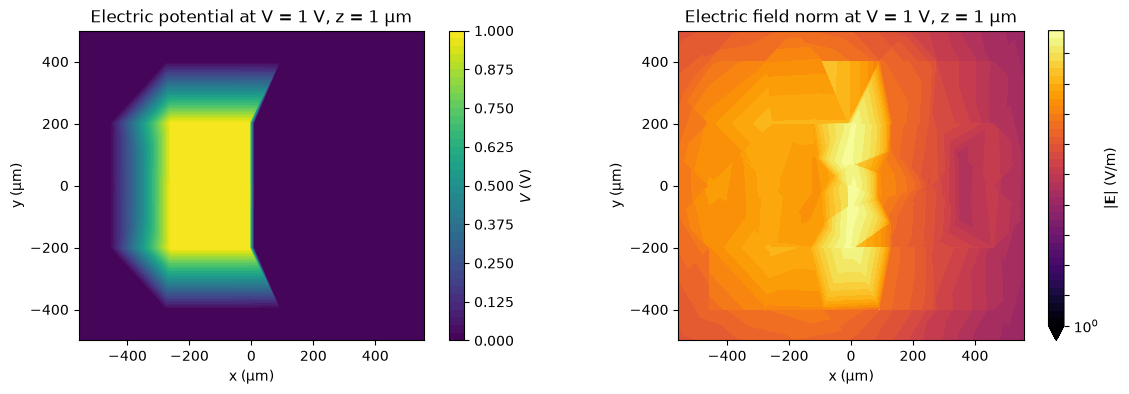

In [10]:
field_file = (
    results_dir / "comsol_qubit_field.txt"
    if results_dir is not None
    else data_path("comsol_qubit_field.txt")
)
field = np.loadtxt(field_file, comments="%")
field_x, field_y = field[:, 0], field[:, 1]
field_v, field_e = field[:, 3], field[:, 4]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
potential = axes[0].tricontourf(field_x, field_y, field_v, levels=40, cmap="viridis")
axes[0].set_title(f"Electric potential at V = {voltage_v:g} V, z = 1 µm")
fig.colorbar(potential, ax=axes[0], label=r"$V$ (V)")

norm_e = axes[1].tricontourf(
    field_x,
    field_y,
    field_e,
    levels=np.geomspace(1.0, field_e.max(), 40),
    norm=LogNorm(vmin=1.0, vmax=field_e.max()),
    cmap="inferno",
    extend="min",
)
axes[1].set_title(f"Electric field norm at V = {voltage_v:g} V, z = 1 µm")
fig.colorbar(norm_e, ax=axes[1], label=r"$|\mathbf{E}|$ (V/m)")

for axis in axes:
    axis.set_aspect("equal")
    axis.set_xlabel("x (µm)")
    axis.set_ylabel("y (µm)")
plt.tight_layout()
plt.show()

The potential is near its terminal value over the driven pad and falls to zero
across the gap to the grounded pad and ground plane. The field is concentrated
in that gap and at the pad edges, which is where the pad capacitance mainly
lives, and it is why the mesh has to resolve the gap and the metal edges for
the capacitance to converge.

## Summary

1. Built a QPDK `double_pad_transmon_with_bbox` cell and made an EM-only copy
   with `JJ_AREA`/`JJ_PATCH` removed, so the SQUID and its leads are not in the
   solved geometry.
2. Extracted the two pad polygons and the ground plane with
   `prepare_comsol_layout(..., feed_ports=None)`.
3. Built the COMSOL sheet model and added an Electrostatics study: a voltage
   terminal on the left pad, ground on the right pad and the ground plane, a
   mesh, and a stationary study.
4. Read back `es.C11` and `es.intWe`, checked them against each other through
   $2 W_e / V^2$, and repeated the exported potential and field map.

### Limitations

- The solve is electrostatic; the metal is a perfect conductor and there is no
  Josephson inductance, so no resonance is solved.
- The `f_LC` number uses a chosen $L_J$ and $C_{11}$ in place of a two-pad
  differential capacitance. It is not a transmon eigenfrequency or $f_{01}$.
- The EM-only copy omits the SQUID loop and its leads, so their parasitic
  capacitance is missing from $C_{11}$.
- The mesh is a single automatic setting; no convergence study was run.

### Next steps

- Extract the two-pad capacitance matrix, then use its differential-mode
  capacitance with a junction model in the QPDK Hamiltonian workflow
  ({doc}`/notebooks/scqubits_parameter_calculation`).
- Refine the mesh at the pad gap and the metal edges and confirm $C_{11}$
  stops moving.

## References

```{bibliography}
:filter: docname in docnames
```